In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_hourly = pd.read_csv("Eureka_Hourly_Data_v1_08132020.csv")
df_daily = pd.read_csv("CrossCheck_Daily_Data.csv")

In [3]:
df_hourly.head()

,study_id,hour,day,filled_pct,accel_mean,app_lists_num_apps_opened_sum,call_log_duration_count_1,call_log_duration_count_2,call_log_duration_count_3,call_log_duration_count_5,call_log_duration_count_6,call_log_duration_sum_1,call_log_duration_sum_2,call_log_duration_sum_3,conversation_duration_count,conversation_duration_sum,distance_sum,loc_1_time,loc_2_time,loc_other_time,screen_locks_screen_sum,screen_sum_1hr_screen_duration_sum,sleep_duration,sleep_end,sleep_start,sms_log_is_read_count_1,sms_log_is_read_count_2,sms_log_is_read_count_3,sms_log_is_read_count_4,sms_log_is_read_count_5,sms_log_is_read_count_6
0,84.0,2015-10-02 00:00:00,2015-10-02 00:00:00,0.769231,9.807737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036047,0.0,0.0,3823.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,84.0,2015-10-02 01:00:00,2015-10-02 01:00:00,0.769231,9.803813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028575,0.0,0.0,3782.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,84.0,2015-10-02 02:00:00,2015-10-02 02:00:00,0.769231,9.804084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018190,0.0,0.0,2893.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,84.0,2015-10-02 03:00:00,2015-10-02 03:00:00,0.769231,9.802508,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036646,0.0,0.0,3675.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,84.0,2015-10-02 04:00:00,2015-10-02 04:00:00,0.692308,9.804349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.052626,0.0,0.0,4200.0,1.0,14.783,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_hourly['study_id'] = df_hourly['study_id'].astype(int)

In [5]:
df_hourly['date'] = pd.to_datetime(df_hourly['day']).dt.date

In [6]:
df_hourly.head()

,study_id,hour,day,filled_pct,accel_mean,app_lists_num_apps_opened_sum,call_log_duration_count_1,call_log_duration_count_2,call_log_duration_count_3,call_log_duration_count_5,call_log_duration_count_6,call_log_duration_sum_1,call_log_duration_sum_2,call_log_duration_sum_3,conversation_duration_count,conversation_duration_sum,distance_sum,loc_1_time,loc_2_time,loc_other_time,screen_locks_screen_sum,screen_sum_1hr_screen_duration_sum,sleep_duration,sleep_end,sleep_start,sms_log_is_read_count_1,sms_log_is_read_count_2,sms_log_is_read_count_3,sms_log_is_read_count_4,sms_log_is_read_count_5,sms_log_is_read_count_6,date
0,84,2015-10-02 00:00:00,2015-10-02 00:00:00,0.769231,9.807737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036047,0.0,0.0,3823.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-10-02
1,84,2015-10-02 01:00:00,2015-10-02 01:00:00,0.769231,9.803813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028575,0.0,0.0,3782.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-10-02
2,84,2015-10-02 02:00:00,2015-10-02 02:00:00,0.769231,9.804084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018190,0.0,0.0,2893.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-10-02
3,84,2015-10-02 03:00:00,2015-10-02 03:00:00,0.769231,9.802508,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036646,0.0,0.0,3675.0,0.0,0.000,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-10-02
4,84,2015-10-02 04:00:00,2015-10-02 04:00:00,0.692308,9.804349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.052626,0.0,0.0,4200.0,1.0,14.783,13.0,104.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-10-02


In [7]:
df_hourly.describe()

,study_id,filled_pct,accel_mean,app_lists_num_apps_opened_sum,call_log_duration_count_1,call_log_duration_count_2,call_log_duration_count_3,call_log_duration_count_5,call_log_duration_count_6,call_log_duration_sum_1,call_log_duration_sum_2,call_log_duration_sum_3,conversation_duration_count,conversation_duration_sum,distance_sum,loc_1_time,loc_2_time,loc_other_time,screen_locks_screen_sum,screen_sum_1hr_screen_duration_sum,sleep_duration,sleep_end,sleep_start,sms_log_is_read_count_1,sms_log_is_read_count_2,sms_log_is_read_count_3,sms_log_is_read_count_4,sms_log_is_read_count_5,sms_log_is_read_count_6
count,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,4.837920e+05,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000,483792.000000
mean,73.658002,0.738209,9.285450,1.221770,0.070490,0.280366,0.051967,0.004829,0.000851,13.114992,22.680513,0.000121,0.944452,525.806559,0.935020,1439.416017,659.601404,1202.632298,2.436121,5.878015e+02,8.644481,99.454939,30.299092,0.249379,0.285749,0.006768,0.000155,0.000522,0.000093
std,45.448772,0.230396,2.275817,4.248275,0.313917,1.047109,0.284439,0.077332,0.041755,107.429154,132.478159,0.063306,1.535581,871.154084,18.091863,1730.959378,1420.607237,1694.245267,4.984257,1.518851e+04,4.050706,34.139564,27.569713,1.416916,1.673014,0.086654,0.010481,0.027637,0.011049
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,0.653846,9.519088,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033753,0.000000,0.000000,0.000000,0.000000,0.000000e+00,6.125000,84.000000,11.092199,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,73.000000,0.769231,9.784255,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.213018,90.000000,0.071620,0.000000,0.000000,0.000000,0.474576,1.428900e+01,8.500000,96.000000,26.023166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,114.000000,1.000000,9.941482,1.000000,0.000000,0.011029,0.000000,0.000000,0.000000,0.000000,0.077778,0.000000,1.089041,684.617424,0.219926,3600.000000,0.000000,3046.000000,3.000000,2.762007e+02,10.750000,113.791367,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,149.000000,1.000000,29.478652,103.000000,12.000000,123.000000,21.000000,11.000000,11.000000,4906.000000,4754.000000,44.000000,22.000000,5915.000000,8261.295497,7124.000000,7038.000000,7171.000000,305.000000,5.006217e+06,23.750000,190.000000,184.000000,85.000000,115.000000,4.000000,1.000000,5.000000,3.000000


In [8]:
df_hourly['study_id'].unique().shape

(61,)

In [9]:
df_daily.head()

,study_id,eureka_id,day,act_in_vehicle_ep_0,act_in_vehicle_ep_1,act_in_vehicle_ep_2,act_in_vehicle_ep_3,act_in_vehicle_ep_4,act_on_bike_ep_0,act_on_bike_ep_1,act_on_bike_ep_2,act_on_bike_ep_3,act_on_bike_ep_4,act_on_foot_ep_0,act_on_foot_ep_1,act_on_foot_ep_2,act_on_foot_ep_3,act_on_foot_ep_4,act_running_ep_0,act_running_ep_1,act_running_ep_2,act_running_ep_3,act_running_ep_4,act_still_ep_0,act_still_ep_1,act_still_ep_2,act_still_ep_3,act_still_ep_4,act_tilting_ep_0,act_tilting_ep_1,act_tilting_ep_2,act_tilting_ep_3,act_tilting_ep_4,act_unknown_ep_0,act_unknown_ep_1,act_unknown_ep_2,act_unknown_ep_3,act_unknown_ep_4,act_walking_ep_0,act_walking_ep_1,act_walking_ep_2,act_walking_ep_3,act_walking_ep_4,audio_amp_mean_ep_0,audio_amp_mean_ep_1,audio_amp_mean_ep_2,audio_amp_mean_ep_3,audio_amp_mean_ep_4,audio_amp_std_ep_0,audio_amp_std_ep_1,audio_amp_std_ep_2,audio_amp_std_ep_3,audio_amp_std_ep_4,audio_convo_duration_ep_0,audio_convo_duration_ep_1,audio_convo_duration_ep_2,audio_convo_duration_ep_3,audio_convo_duration_ep_4,audio_convo_num_ep_0,audio_convo_num_ep_1,audio_convo_num_ep_2,audio_convo_num_ep_3,audio_convo_num_ep_4,audio_voice_ep_0,audio_voice_ep_1,audio_voice_ep_2,audio_voice_ep_3,audio_voice_ep_4,call_in_duration_ep_0,call_in_duration_ep_1,call_in_duration_ep_2,call_in_duration_ep_3,call_in_duration_ep_4,call_in_num_ep_0,call_in_num_ep_1,call_in_num_ep_2,call_in_num_ep_3,call_in_num_ep_4,call_miss_num_ep_0,call_miss_num_ep_1,call_miss_num_ep_2,call_miss_num_ep_3,call_miss_num_ep_4,call_out_duration_ep_0,call_out_duration_ep_1,call_out_duration_ep_2,call_out_duration_ep_3,call_out_duration_ep_4,call_out_num_ep_0,call_out_num_ep_1,call_out_num_ep_2,call_out_num_ep_3,call_out_num_ep_4,ema_CALM,ema_DEPRESSED,ema_HARM,ema_HOPEFUL,ema_SEEING_THINGS,ema_SLEEPING,ema_SOCIAL,ema_STRESSED,ema_THINK,ema_VOICES,ema_neg_score,ema_pos_score,ema_resp_time_median,ema_score,light_mean_ep_0,light_mean_ep_1,light_mean_ep_2,light_mean_ep_3,light_mean_ep_4,light_std_ep_0,light_std_ep_1,light_std_ep_2,light_std_ep_3,light_std_ep_4,loc_dist_ep_0,loc_dist_ep_1,loc_dist_ep_2,loc_dist_ep_3,loc_dist_ep_4,loc_visit_num_ep_0,loc_visit_num_ep_1,loc_visit_num_ep_2,loc_visit_num_ep_3,loc_visit_num_ep_4,quality_activity,quality_audio,quality_gps_on,quality_light,quality_loc,sleep_duration,sleep_end,sleep_start,sms_in_num_ep_0,sms_in_num_ep_1,sms_in_num_ep_2,sms_in_num_ep_3,sms_in_num_ep_4,sms_out_num_ep_0,sms_out_num_ep_1,sms_out_num_ep_2,sms_out_num_ep_3,sms_out_num_ep_4,unlock_duration_ep_0,unlock_duration_ep_1,unlock_duration_ep_2,unlock_duration_ep_3,unlock_duration_ep_4,unlock_num_ep_0,unlock_num_ep_1,unlock_num_ep_2,unlock_num_ep_3,unlock_num_ep_4
0,-1,u004,20150122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,23.75,190,0,1,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
1,-1,u004,20150123,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,23.75,190,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0
2,-1,u004,20150124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [10]:
df_daily.describe()

,study_id,day,act_in_vehicle_ep_0,act_in_vehicle_ep_1,act_in_vehicle_ep_2,act_in_vehicle_ep_3,act_in_vehicle_ep_4,act_on_bike_ep_0,act_on_bike_ep_1,act_on_bike_ep_2,act_on_bike_ep_3,act_on_bike_ep_4,act_on_foot_ep_0,act_on_foot_ep_1,act_on_foot_ep_2,act_on_foot_ep_3,act_on_foot_ep_4,act_running_ep_0,act_running_ep_1,act_running_ep_2,act_running_ep_3,act_running_ep_4,act_still_ep_0,act_still_ep_1,act_still_ep_2,act_still_ep_3,act_still_ep_4,act_tilting_ep_0,act_tilting_ep_1,act_tilting_ep_2,act_tilting_ep_3,act_tilting_ep_4,act_unknown_ep_0,act_unknown_ep_1,act_unknown_ep_2,act_unknown_ep_3,act_unknown_ep_4,act_walking_ep_0,act_walking_ep_1,act_walking_ep_2,act_walking_ep_3,act_walking_ep_4,audio_amp_mean_ep_0,audio_amp_mean_ep_1,audio_amp_mean_ep_2,audio_amp_mean_ep_3,audio_amp_mean_ep_4,audio_amp_std_ep_0,audio_amp_std_ep_1,audio_amp_std_ep_2,audio_amp_std_ep_3,audio_amp_std_ep_4,audio_convo_duration_ep_0,audio_convo_duration_ep_1,audio_convo_duration_ep_2,audio_convo_duration_ep_3,audio_convo_duration_ep_4,audio_convo_num_ep_0,audio_convo_num_ep_1,audio_convo_num_ep_2,audio_convo_num_ep_3,audio_convo_num_ep_4,audio_voice_ep_0,audio_voice_ep_1,audio_voice_ep_2,audio_voice_ep_3,audio_voice_ep_4,call_in_duration_ep_0,call_in_duration_ep_1,call_in_duration_ep_2,call_in_duration_ep_3,call_in_duration_ep_4,call_in_num_ep_0,call_in_num_ep_1,call_in_num_ep_2,call_in_num_ep_3,call_in_num_ep_4,call_miss_num_ep_0,call_miss_num_ep_1,call_miss_num_ep_2,call_miss_num_ep_3,call_miss_num_ep_4,call_out_duration_ep_0,call_out_duration_ep_1,call_out_duration_ep_2,call_out_duration_ep_3,call_out_duration_ep_4,call_out_num_ep_0,call_out_num_ep_1,call_out_num_ep_2,call_out_num_ep_3,call_out_num_ep_4,ema_CALM,ema_DEPRESSED,ema_HARM,ema_HOPEFUL,ema_SEEING_THINGS,ema_SLEEPING,ema_SOCIAL,ema_STRESSED,ema_THINK,ema_VOICES,ema_neg_score,ema_pos_score,ema_resp_time_median,ema_score,light_mean_ep_0,light_mean_ep_1,light_mean_ep_2,light_mean_ep_3,light_mean_ep_4,light_std_ep_0,light_std_ep_1,light_std_ep_2,light_std_ep_3,light_std_ep_4,loc_dist_ep_0,loc_dist_ep_1,loc_dist_ep_2,loc_dist_ep_3,loc_dist_ep_4,loc_visit_num_ep_0,loc_visit_num_ep_1,loc_visit_num_ep_2,loc_visit_num_ep_3,loc_visit_num_ep_4,quality_activity,quality_audio,quality_gps_on,quality_light,quality_loc,sleep_duration,sleep_end,sleep_start,sms_in_num_ep_0,sms_in_num_ep_1,sms_in_num_ep_2,sms_in_num_ep_3,sms_in_num_ep_4,sms_out_num_ep_0,sms_out_num_ep_1,sms_out_num_ep_2,sms_out_num_ep_3,sms_out_num_ep_4,unlock_duration_ep_0,unlock_duration_ep_1,unlock_duration_ep_2,unlock_duration_ep_3,unlock_duration_ep_4,unlock_num_ep_0,unlock_num_ep_1,unlock_num_ep_2,unlock_num_ep_3,unlock_num_ep_4
count,23573.000000,2.357300e+04,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.0,23573.0,23573.0,23573.0,23573.0,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.0,23573.0,23573.0,23573.0,23573.0,17169.000000,15208.000000,15960.000000,16343.000000,15875.000000,17169.000000,15208.000000,15960.000000,16343.000000,15875.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.0,23573.0,23573.0,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,23573.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,6364.000000,17528.000000,15943.000000,16

In [11]:
df_daily['date'] = pd.to_datetime(df_daily['day'], format='%Y%m%d').dt.date

In [12]:
df_daily.head()

,study_id,eureka_id,day,act_in_vehicle_ep_0,act_in_vehicle_ep_1,act_in_vehicle_ep_2,act_in_vehicle_ep_3,act_in_vehicle_ep_4,act_on_bike_ep_0,act_on_bike_ep_1,act_on_bike_ep_2,act_on_bike_ep_3,act_on_bike_ep_4,act_on_foot_ep_0,act_on_foot_ep_1,act_on_foot_ep_2,act_on_foot_ep_3,act_on_foot_ep_4,act_running_ep_0,act_running_ep_1,act_running_ep_2,act_running_ep_3,act_running_ep_4,act_still_ep_0,act_still_ep_1,act_still_ep_2,act_still_ep_3,act_still_ep_4,act_tilting_ep_0,act_tilting_ep_1,act_tilting_ep_2,act_tilting_ep_3,act_tilting_ep_4,act_unknown_ep_0,act_unknown_ep_1,act_unknown_ep_2,act_unknown_ep_3,act_unknown_ep_4,act_walking_ep_0,act_walking_ep_1,act_walking_ep_2,act_walking_ep_3,act_walking_ep_4,audio_amp_mean_ep_0,audio_amp_mean_ep_1,audio_amp_mean_ep_2,audio_amp_mean_ep_3,audio_amp_mean_ep_4,audio_amp_std_ep_0,audio_amp_std_ep_1,audio_amp_std_ep_2,audio_amp_std_ep_3,audio_amp_std_ep_4,audio_convo_duration_ep_0,audio_convo_duration_ep_1,audio_convo_duration_ep_2,audio_convo_duration_ep_3,audio_convo_duration_ep_4,audio_convo_num_ep_0,audio_convo_num_ep_1,audio_convo_num_ep_2,audio_convo_num_ep_3,audio_convo_num_ep_4,audio_voice_ep_0,audio_voice_ep_1,audio_voice_ep_2,audio_voice_ep_3,audio_voice_ep_4,call_in_duration_ep_0,call_in_duration_ep_1,call_in_duration_ep_2,call_in_duration_ep_3,call_in_duration_ep_4,call_in_num_ep_0,call_in_num_ep_1,call_in_num_ep_2,call_in_num_ep_3,call_in_num_ep_4,call_miss_num_ep_0,call_miss_num_ep_1,call_miss_num_ep_2,call_miss_num_ep_3,call_miss_num_ep_4,call_out_duration_ep_0,call_out_duration_ep_1,call_out_duration_ep_2,call_out_duration_ep_3,call_out_duration_ep_4,call_out_num_ep_0,call_out_num_ep_1,call_out_num_ep_2,call_out_num_ep_3,call_out_num_ep_4,ema_CALM,ema_DEPRESSED,ema_HARM,ema_HOPEFUL,ema_SEEING_THINGS,ema_SLEEPING,ema_SOCIAL,ema_STRESSED,ema_THINK,ema_VOICES,ema_neg_score,ema_pos_score,ema_resp_time_median,ema_score,light_mean_ep_0,light_mean_ep_1,light_mean_ep_2,light_mean_ep_3,light_mean_ep_4,light_std_ep_0,light_std_ep_1,light_std_ep_2,light_std_ep_3,light_std_ep_4,loc_dist_ep_0,loc_dist_ep_1,loc_dist_ep_2,loc_dist_ep_3,loc_dist_ep_4,loc_visit_num_ep_0,loc_visit_num_ep_1,loc_visit_num_ep_2,loc_visit_num_ep_3,loc_visit_num_ep_4,quality_activity,quality_audio,quality_gps_on,quality_light,quality_loc,sleep_duration,sleep_end,sleep_start,sms_in_num_ep_0,sms_in_num_ep_1,sms_in_num_ep_2,sms_in_num_ep_3,sms_in_num_ep_4,sms_out_num_ep_0,sms_out_num_ep_1,sms_out_num_ep_2,sms_out_num_ep_3,sms_out_num_ep_4,unlock_duration_ep_0,unlock_duration_ep_1,unlock_duration_ep_2,unlock_duration_ep_3,unlock_duration_ep_4,unlock_num_ep_0,unlock_num_ep_1,unlock_num_ep_2,unlock_num_ep_3,unlock_num_ep_4,date
0,-1,u004,20150122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,23.75,190,0,1,0,1,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2015-01-22
1,-1,u004,20150123,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0,0.0,23.75,190,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2015-01-23
2,-1,u004,20150124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86399,21599,21600,21600,21600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [13]:
df_daily['study_id'].unique().shape

(62,)

In [14]:
common_patients = set(df_hourly['study_id']).intersection(set(df_daily['study_id']))

df_h = df_hourly[df_hourly['study_id'].isin(common_patients)].copy()
df_d = df_daily[df_daily['study_id'].isin(common_patients)].copy()

In [15]:
print("Columns in df_h:", df_h.columns.tolist())
print("-" * 100)
print("Columns in df_d:", df_d.columns.tolist())

Columns in df_h: ['study_id', 'hour', 'day', 'filled_pct', 'accel_mean', 'app_lists_num_apps_opened_sum', 'call_log_duration_count_1', 'call_log_duration_count_2', 'call_log_duration_count_3', 'call_log_duration_count_5', 'call_log_duration_count_6', 'call_log_duration_sum_1', 'call_log_duration_sum_2', 'call_log_duration_sum_3', 'conversation_duration_count', 'conversation_duration_sum', 'distance_sum', 'loc_1_time', 'loc_2_time', 'loc_other_time', 'screen_locks_screen_sum', 'screen_sum_1hr_screen_duration_sum', 'sleep_duration', 'sleep_end', 'sleep_start', 'sms_log_is_read_count_1', 'sms_log_is_read_count_2', 'sms_log_is_read_count_3', 'sms_log_is_read_count_4', 'sms_log_is_read_count_5', 'sms_log_is_read_count_6', 'date']
----------------------------------------------------------------------------------------------------
Columns in df_d: ['study_id', 'eureka_id', 'day', 'act_in_vehicle_ep_0', 'act_in_vehicle_ep_1', 'act_in_vehicle_ep_2', 'act_in_vehicle_ep_3', 'act_in_vehicle_ep_4',

In [16]:
print(df_h.columns)

Index(['study_id', 'hour', 'day', 'filled_pct', 'accel_mean',
       'app_lists_num_apps_opened_sum', 'call_log_duration_count_1',
       'call_log_duration_count_2', 'call_log_duration_count_3',
       'call_log_duration_count_5', 'call_log_duration_count_6',
       'call_log_duration_sum_1', 'call_log_duration_sum_2',
       'call_log_duration_sum_3', 'conversation_duration_count',
       'conversation_duration_sum', 'distance_sum', 'loc_1_time', 'loc_2_time',
       'loc_other_time', 'screen_locks_screen_sum',
       'screen_sum_1hr_screen_duration_sum', 'sleep_duration', 'sleep_end',
       'sleep_start', 'sms_log_is_read_count_1', 'sms_log_is_read_count_2',
       'sms_log_is_read_count_3', 'sms_log_is_read_count_4',
       'sms_log_is_read_count_5', 'sms_log_is_read_count_6', 'date'],
      dtype='object')


In [17]:
sensor_cols = [
    'accel_mean'
    'distance_sum',
    'audio_inference',
    'screen_on',
    'screen_locks_screen_sum',
    'screen_sum_1hr_screen_duration_sum',
    'sleep_duration',
    'gps_radius',
    'conversation_duration_count',
    'sms_count',
    'conversation_duration_sum'
]

sensor_cols = [c for c in sensor_cols if c in df_h.columns]

In [18]:
feature_cols = [col for col in sensor_cols if col in df_h.columns]

print("Using features:", feature_cols)

Using features: ['screen_locks_screen_sum', 'screen_sum_1hr_screen_duration_sum', 'sleep_duration', 'conversation_duration_count', 'conversation_duration_sum']


In [19]:
def slope(series):
    if len(series) < 2:
        return 0
    x = np.arange(len(series))
    return linregress(x, series).slope

In [20]:
agg_dict = {}

for col in sensor_cols:
    agg_dict[col] = ['mean','std','min','max', slope]

df_hourly_features = df_h.groupby(['study_id','date']).agg(agg_dict)

df_hourly_features.columns = ['_'.join(col) for col in df_hourly_features.columns]

df_hourly_features = df_hourly_features.reset_index()

In [21]:
df_hourly_features.head()

,study_id,date,screen_locks_screen_sum_mean,screen_locks_screen_sum_std,screen_locks_screen_sum_min,screen_locks_screen_sum_max,screen_locks_screen_sum_slope,screen_sum_1hr_screen_duration_sum_mean,screen_sum_1hr_screen_duration_sum_std,screen_sum_1hr_screen_duration_sum_min,screen_sum_1hr_screen_duration_sum_max,screen_sum_1hr_screen_duration_sum_slope,sleep_duration_mean,sleep_duration_std,sleep_duration_min,sleep_duration_max,sleep_duration_slope,conversation_duration_count_mean,conversation_duration_count_std,conversation_duration_count_min,conversation_duration_count_max,conversation_duration_count_slope,conversation_duration_sum_mean,conversation_duration_sum_std,conversation_duration_sum_min,conversation_duration_sum_max,conversation_duration_sum_slope
0,2,2015-03-18,1.916667,2.685171,0.0,8.000000,0.021739,167.136833,364.910421,0.0,1462.110000,-5.284886,3.750000,0.000000,3.750000,3.75,0.000000,0.291667,0.624094,0.0,2.000000,0.003043,144.625000,403.430271,0.0,1866.000000,-1.844783
1,2,2015-03-19,2.862244,4.410014,0.0,16.000000,0.189060,152.145247,241.725774,0.0,936.823427,17.670879,12.553808,1.205971,9.392483,13.00,-0.097824,0.354731,0.619504,0.0,2.000000,0.019994,399.602416,861.273810,0.0,3317.000000,19.681653
2,2,2015-03-20,2.079630,1.682138,0.0,4.580756,0.095479,322.296358,792.005659,0.0,3927.936598,-6.333994,12.326584,5.689511,8.452665,21.00,0.647182,0.562214,0.593788,0.0,1.603448,0.015085,327.785172,353.763719,0.0,1036.810345,5.894186
3,2,2015-03-21,1.791667,3.599265,0.0,17.000000,0.216957,161.293472,272.156054,0.0,810.292333,16.845330,9.750000,0.000000,9.750000,9.75,0.000000,0.708333,0.999094,0.0,3.000000,0.058696,554.375000,909.008433,0.0,3184.000000,49.200435
4,2,2015-03-22,0.250000,0.607919,0.0,2.000000,0.001739,7.096583,18.423416,0.0,69.024000,0.213921,3.750000,0.000000,3.750000,3.75,0.000000,0.208333,0.588230,0.0,2.000000,0.015217,27.916667,78.683691,0.0,310.000000,2.021739


In [22]:
df = pd.merge(
    df_d,
    df_hourly_features,
    on=['study_id','date'],
    how='inner'
)

In [23]:
df.head(20)

,study_id,eureka_id,day,act_in_vehicle_ep_0,act_in_vehicle_ep_1,act_in_vehicle_ep_2,act_in_vehicle_ep_3,act_in_vehicle_ep_4,act_on_bike_ep_0,act_on_bike_ep_1,act_on_bike_ep_2,act_on_bike_ep_3,act_on_bike_ep_4,act_on_foot_ep_0,act_on_foot_ep_1,act_on_foot_ep_2,act_on_foot_ep_3,act_on_foot_ep_4,act_running_ep_0,act_running_ep_1,act_running_ep_2,act_running_ep_3,act_running_ep_4,act_still_ep_0,act_still_ep_1,act_still_ep_2,act_still_ep_3,act_still_ep_4,act_tilting_ep_0,act_tilting_ep_1,act_tilting_ep_2,act_tilting_ep_3,act_tilting_ep_4,act_unknown_ep_0,act_unknown_ep_1,act_unknown_ep_2,act_unknown_ep_3,act_unknown_ep_4,act_walking_ep_0,act_walking_ep_1,act_walking_ep_2,act_walking_ep_3,act_walking_ep_4,audio_amp_mean_ep_0,audio_amp_mean_ep_1,audio_amp_mean_ep_2,audio_amp_mean_ep_3,audio_amp_mean_ep_4,audio_amp_std_ep_0,audio_amp_std_ep_1,audio_amp_std_ep_2,audio_amp_std_ep_3,audio_amp_std_ep_4,audio_convo_duration_ep_0,audio_convo_duration_ep_1,audio_convo_duration_ep_2,audio_convo_duration_ep_3,audio_convo_duration_ep_4,audio_convo_num_ep_0,audio_convo_num_ep_1,audio_convo_num_ep_2,audio_convo_num_ep_3,audio_convo_num_ep_4,audio_voice_ep_0,audio_voice_ep_1,audio_voice_ep_2,audio_voice_ep_3,audio_voice_ep_4,call_in_duration_ep_0,call_in_duration_ep_1,call_in_duration_ep_2,call_in_duration_ep_3,call_in_duration_ep_4,call_in_num_ep_0,call_in_num_ep_1,call_in_num_ep_2,call_in_num_ep_3,call_in_num_ep_4,call_miss_num_ep_0,call_miss_num_ep_1,call_miss_num_ep_2,call_miss_num_ep_3,call_miss_num_ep_4,call_out_duration_ep_0,call_out_duration_ep_1,call_out_duration_ep_2,call_out_duration_ep_3,call_out_duration_ep_4,call_out_num_ep_0,call_out_num_ep_1,call_out_num_ep_2,call_out_num_ep_3,call_out_num_ep_4,ema_CALM,ema_DEPRESSED,ema_HARM,ema_HOPEFUL,ema_SEEING_THINGS,ema_SLEEPING,ema_SOCIAL,ema_STRESSED,ema_THINK,ema_VOICES,ema_neg_score,ema_pos_score,ema_resp_time_median,ema_score,light_mean_ep_0,light_mean_ep_1,light_mean_ep_2,light_mean_ep_3,light_mean_ep_4,light_std_ep_0,light_std_ep_1,light_std_ep_2,light_std_ep_3,light_std_ep_4,loc_dist_ep_0,loc_dist_ep_1,loc_dist_ep_2,loc_dist_ep_3,loc_dist_ep_4,loc_visit_num_ep_0,loc_visit_num_ep_1,loc_visit_num_ep_2,loc_visit_num_ep_3,loc_visit_num_ep_4,quality_activity,quality_audio,quality_gps_on,quality_light,quality_loc,sleep_duration,sleep_end,sleep_start,sms_in_num_ep_0,sms_in_num_ep_1,sms_in_num_ep_2,sms_in_num_ep_3,sms_in_num_ep_4,sms_out_num_ep_0,sms_out_num_ep_1,sms_out_num_ep_2,sms_out_num_ep_3,sms_out_num_ep_4,unlock_duration_ep_0,unlock_duration_ep_1,unlock_duration_ep_2,unlock_duration_ep_3,unlock_duration_ep_4,unlock_num_ep_0,unlock_num_ep_1,unlock_num_ep_2,unlock_num_ep_3,unlock_num_ep_4,date,screen_locks_screen_sum_mean,screen_locks_screen_sum_std,screen_locks_screen_sum_min,screen_locks_screen_sum_max,screen_locks_screen_sum_slope,screen_sum_1hr_screen_duration_sum_mean,screen_sum_1hr_screen_duration_sum_std,screen_sum_1hr_screen_duration_sum_min,screen_sum_1hr_screen_duration_sum_max,screen_sum_1hr_screen_duration_sum_slope,sleep_duration_mean,sleep_duration_std,sleep_duration_min,sleep_duration_max,sleep_duration_slope,conversation_duration_count_mean,conversation_duration_count_std,conversation_duration_count_min,conversation_duration_count_max,conversation_duration_count_slope,conversation_duration_sum_mean,conversation_duration_sum_std,conversation_duration_sum_min,conversation_duration_sum_max,conversation_duration_sum_slope
0,84,u005,20151002,87,0,29,58,0,0,0,0,0,0,168,0,20,148,0,0,0,0,0,0,84577,21599,20306,21072,21600,1403,0,1151,252,0,164,0,94,70,0,0,0,0,0,0,151.546025,10.249143,356.488207,137.791205,79.894174,572.079216,25.691496,1027.366920,305.373785,75.077682,520.0,0.0,520.0,0.0,0.0,2,0,2,0,0,0.012637,0.000000,0.043270,0.003442,0.000419,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,69.0,0.0,0.0,69.0,0.0,1,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.829658,0.000000,0.196528,3.121528,0.000000,1.913628e+03,0.00000,6.149571e+00,7.640005e+03,0.000000,67.078999

In [24]:
len(list(df["study_id"].unique()))

61

In [25]:
df.shape

(18580, 181)

In [26]:
df["study_id"].unique()

array([ 84,  16,   2,   6,   3,  18,  15,  12,  11,   8,  43,  34,  24,
        20,  26,  38,  46,  22,  28,  64,  40,  52,  72,  73,  44,  47,
        77,  59,  33,  54,  63, 138,  70,  53,  95,  97,  92,  83, 100,
       107, 109, 102, 110, 105, 126, 113, 118, 124, 117, 114, 141, 135,
       147, 125, 123, 132, 139, 146, 149, 131,  91])

In [27]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

ema_resp_time_median    12505
ema_VOICES              12505
ema_THINK               12505
ema_DEPRESSED           12505
ema_CALM                12505
ema_pos_score           12505
ema_neg_score           12505
ema_STRESSED            12505
ema_SOCIAL              12505
ema_HOPEFUL             12505
ema_HARM                12505
ema_SLEEPING            12505
ema_SEEING_THINGS       12505
ema_score               12505
audio_amp_std_ep_1       4162
audio_amp_mean_ep_1      4162
audio_amp_std_ep_2       3681
audio_amp_mean_ep_2      3681
audio_amp_std_ep_4       3549
audio_amp_mean_ep_4      3549
dtype: int64


In [28]:
drop_cols = [
    'study_id',
    'date'
]

X = df.drop(columns=drop_cols)

In [29]:
print(df.columns)

Index(['study_id', 'eureka_id', 'day', 'act_in_vehicle_ep_0',
       'act_in_vehicle_ep_1', 'act_in_vehicle_ep_2', 'act_in_vehicle_ep_3',
       'act_in_vehicle_ep_4', 'act_on_bike_ep_0', 'act_on_bike_ep_1',
       ...
       'conversation_duration_count_mean', 'conversation_duration_count_std',
       'conversation_duration_count_min', 'conversation_duration_count_max',
       'conversation_duration_count_slope', 'conversation_duration_sum_mean',
       'conversation_duration_sum_std', 'conversation_duration_sum_min',
       'conversation_duration_sum_max', 'conversation_duration_sum_slope'],
      dtype='object', length=181)


In [30]:
threshold = df['ema_neg_score'].quantile(0.75)

df['relapse'] = (df['ema_neg_score'] > threshold).astype(int)

In [31]:
df["relapse"].value_counts()

relapse
0    17062
1     1518
Name: count, dtype: int64

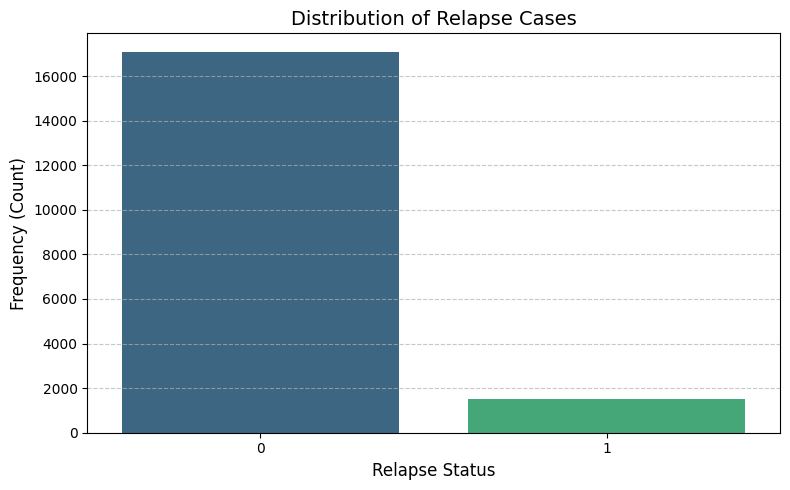

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(x='relapse', data=df, palette='viridis', order=df['relapse'].value_counts().index)

plt.title('Distribution of Relapse Cases', fontsize=14)
plt.xlabel('Relapse Status', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [33]:
y = df['relapse']

In [34]:
print(X.dtypes[X.dtypes == 'object'])

eureka_id    object
dtype: object


In [35]:
X = X.drop(columns=['eureka_id'])

In [36]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(X_imputed, columns=X.columns)

In [37]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

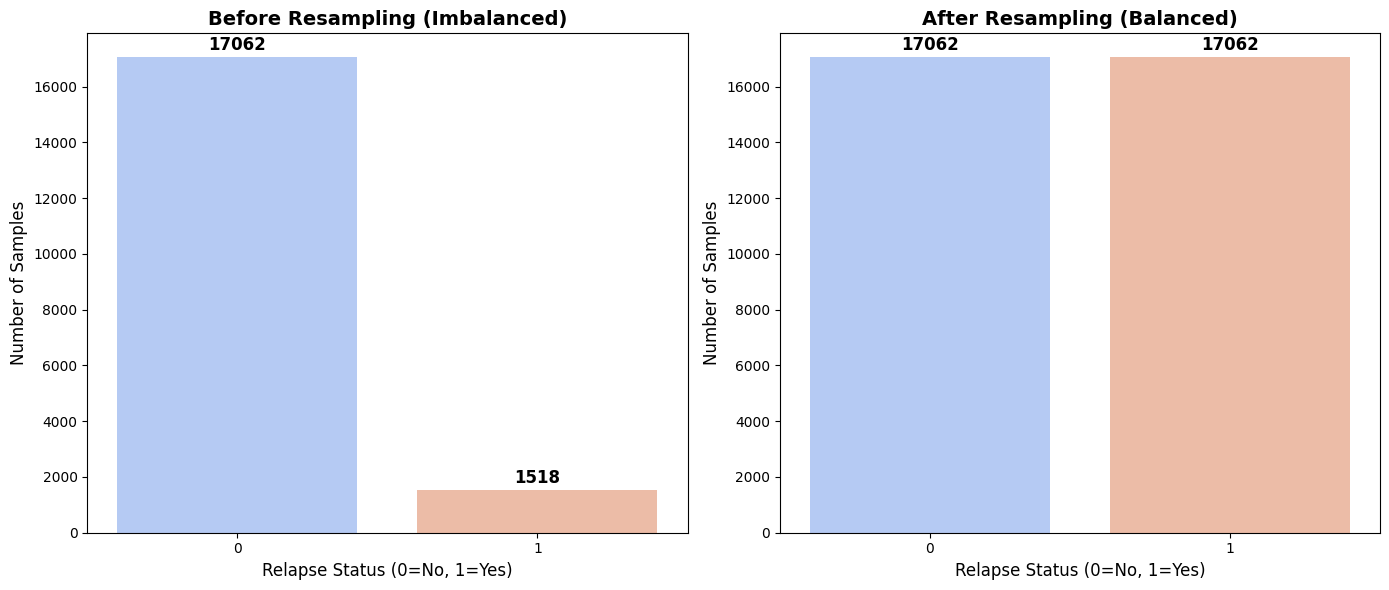

In [38]:
before_counts = pd.Series(y).value_counts()
after_counts = pd.Series(y_res).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=before_counts.index, y=before_counts.values, palette='coolwarm', ax=ax1)
ax1.set_title('Before Resampling (Imbalanced)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Relapse Status (0=No, 1=Yes)', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)

sns.barplot(x=after_counts.index, y=after_counts.values, palette='coolwarm', ax=ax2)
ax2.set_title('After Resampling (Balanced)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Relapse Status (0=No, 1=Yes)', fontsize=12)
ax2.set_ylabel('Number of Samples', fontsize=12)

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

add_labels(ax1)
add_labels(ax2)

plt.tight_layout()
plt.show()

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_res)

---

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_res,
    test_size=0.30,
    random_state=42,
    stratify=y_res
)

In [41]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [42]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(23886, 178)
(5119, 178)
(5119, 178)


---

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
from sklearn.metrics import classification_report, roc_auc_score

val_pred = rf.predict(X_val)
val_prob = rf.predict_proba(X_val)[:,1]

print(classification_report(y_val, val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, val_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2559
           1       1.00      1.00      1.00      2560

    accuracy                           1.00      5119
   macro avg       1.00      1.00      1.00      5119
weighted avg       1.00      1.00      1.00      5119

Validation ROC AUC: 1.0


In [45]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X_res.columns
)

In [46]:
importance = importance.sort_values(ascending=False)

print(importance.head(20))

ema_neg_score           0.183766
ema_score               0.122491
ema_STRESSED            0.096513
ema_DEPRESSED           0.089231
ema_HARM                0.077949
ema_VOICES              0.068356
ema_SEEING_THINGS       0.058716
ema_HOPEFUL             0.052153
ema_SOCIAL              0.037523
ema_pos_score           0.036800
ema_CALM                0.023741
ema_THINK               0.023689
ema_SLEEPING            0.016679
ema_resp_time_median    0.011847
unlock_duration_ep_4    0.006094
unlock_num_ep_3         0.005761
unlock_duration_ep_3    0.004437
unlock_duration_ep_0    0.003622
act_still_ep_0          0.003484
call_out_num_ep_0       0.003076
dtype: float64


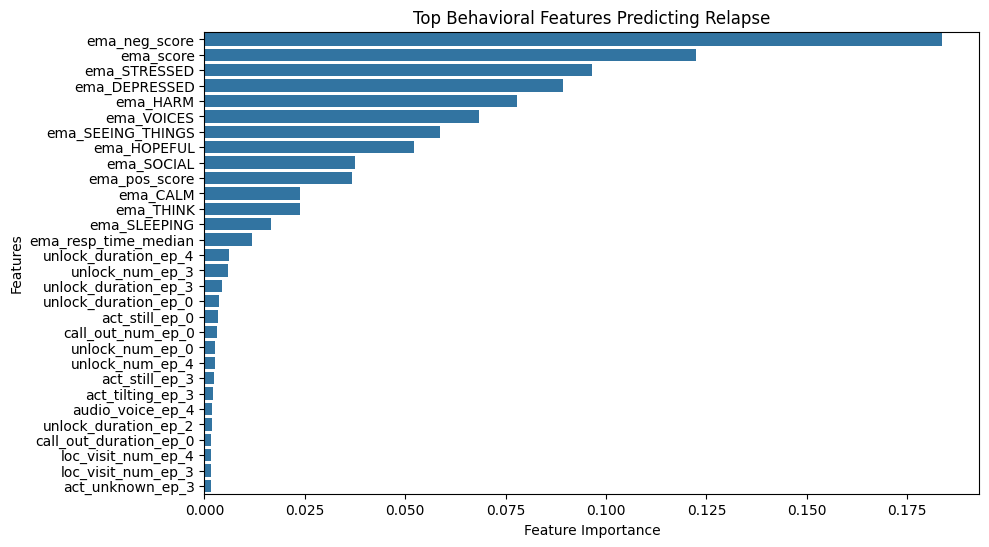

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = importance.head(30)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Behavioral Features Predicting Relapse")

plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

In [48]:
top_30 = importance.head(30).index

X_train_sel = X_train[:, [X_res.columns.get_loc(c) for c in top_30]]
X_val_sel = X_val[:, [X_res.columns.get_loc(c) for c in top_30]]
X_test_sel = X_test[:, [X_res.columns.get_loc(c) for c in top_30]]

In [49]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf_final.fit(X_train_sel, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
from sklearn.metrics import classification_report, roc_auc_score

val_pred = rf_final.predict(X_val_sel)
val_prob = rf_final.predict_proba(X_val_sel)[:,1]

print(classification_report(y_val, val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, val_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2559
           1       1.00      1.00      1.00      2560

    accuracy                           1.00      5119
   macro avg       1.00      1.00      1.00      5119
weighted avg       1.00      1.00      1.00      5119

Validation ROC AUC: 1.0


In [51]:
test_pred = rf_final.predict(X_test_sel)
test_prob = rf_final.predict_proba(X_test_sel)[:,1]

print(classification_report(y_test, test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, test_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2560
           1       1.00      1.00      1.00      2559

    accuracy                           1.00      5119
   macro avg       1.00      1.00      1.00      5119
weighted avg       1.00      1.00      1.00      5119

Test ROC AUC: 1.0


---

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.optim as optim

In [53]:
feature_cols = [
    'conversation_duration_sum',
    'distance_sum',
    'accel_mean',
    'screen_sum_1hr_screen_duration_sum',
    'sleep_duration'
]

In [54]:
def build_patient_graph(df_h):

    graph_features = [
        'conversation_duration_sum',
        'distance_sum',
        'accel_mean',
        'screen_sum_1hr_screen_duration_sum'
    ]

    baseline = df_h.groupby('study_id')[graph_features].mean().fillna(0)

    scaler = StandardScaler()
    baseline_scaled = scaler.fit_transform(baseline)

    similarity_matrix = cosine_similarity(baseline_scaled)

    return baseline, similarity_matrix

In [55]:
def get_similar_peers(patient_id, baseline_df, similarity_matrix, top_n=5):

    patients = baseline_df.index.tolist()

    if patient_id not in patients:
        return []

    idx = patients.index(patient_id)

    sims = similarity_matrix[idx]

    sorted_idx = np.argsort(sims)[::-1]

    neighbors = []

    for i in sorted_idx:
        if i != idx:
            neighbors.append(patients[i])

        if len(neighbors) >= top_n:
            break

    return neighbors

In [56]:
def create_sequences(df, window_days=7):

    X, y = [], []

    df = df.sort_values(['study_id', 'day'])

    patients = df['study_id'].unique()

    for pid in patients:

        pdata = df[df['study_id'] == pid]

        days = pdata['day'].unique()

        for i in range(len(days) - window_days):

            window_days_list = days[i:i + window_days]

            seq = pdata[pdata['day'].isin(window_days_list)][feature_cols].values

            if len(seq) < window_days * 24:
                continue

            seq = seq[:window_days * 24]

            target_day = days[i + window_days]

            label_row = pdata[pdata['day'] == target_day]

            if len(label_row) == 0:
                continue

            label = 1 if label_row['ema_score'].iloc[0] < -3 else 0

            X.append(seq)
            y.append(label)

    return np.array(X), np.array(y)

In [57]:
print(df['day'].dtype)

int64


In [58]:
feature_cols = [col for col in feature_cols if col in df_h.columns]

print("Using features:", feature_cols)

Using features: ['conversation_duration_sum', 'distance_sum', 'accel_mean', 'screen_sum_1hr_screen_duration_sum', 'sleep_duration']


In [59]:
from sklearn.model_selection import train_test_split

X, y = create_sequences(df_h)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [60]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=2000)

scores = cross_val_score(lr, X_train_flat, y_train, cv=5)

print("Logistic Regression CV Accuracy:", scores.mean())

Logistic Regression CV Accuracy: 0.9997906811214227


In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)

scores = cross_val_score(rf, X_train_flat, y_train, cv=5)

print("Random Forest CV Accuracy:", scores.mean())

Random Forest CV Accuracy: 1.0


In [63]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

scores = cross_val_score(gb, X_train_flat, y_train, cv=5)

print("Gradient Boosting CV Accuracy:", scores.mean())

Gradient Boosting CV Accuracy: 1.0


In [75]:
exclude_cols = [
    'study_id',
    'date',
    'relapse',
    'ema_score'
]

feature_cols = []

for col in df.columns:

    if col in exclude_cols:
        continue

    if pd.api.types.is_numeric_dtype(df[col]):
        feature_cols.append(col)

print("Total Features:", len(feature_cols))
print(feature_cols)

Total Features: 177
['day', 'act_in_vehicle_ep_0', 'act_in_vehicle_ep_1', 'act_in_vehicle_ep_2', 'act_in_vehicle_ep_3', 'act_in_vehicle_ep_4', 'act_on_bike_ep_0', 'act_on_bike_ep_1', 'act_on_bike_ep_2', 'act_on_bike_ep_3', 'act_on_bike_ep_4', 'act_on_foot_ep_0', 'act_on_foot_ep_1', 'act_on_foot_ep_2', 'act_on_foot_ep_3', 'act_on_foot_ep_4', 'act_running_ep_0', 'act_running_ep_1', 'act_running_ep_2', 'act_running_ep_3', 'act_running_ep_4', 'act_still_ep_0', 'act_still_ep_1', 'act_still_ep_2', 'act_still_ep_3', 'act_still_ep_4', 'act_tilting_ep_0', 'act_tilting_ep_1', 'act_tilting_ep_2', 'act_tilting_ep_3', 'act_tilting_ep_4', 'act_unknown_ep_0', 'act_unknown_ep_1', 'act_unknown_ep_2', 'act_unknown_ep_3', 'act_unknown_ep_4', 'act_walking_ep_0', 'act_walking_ep_1', 'act_walking_ep_2', 'act_walking_ep_3', 'act_walking_ep_4', 'audio_amp_mean_ep_0', 'audio_amp_mean_ep_1', 'audio_amp_mean_ep_2', 'audio_amp_mean_ep_3', 'audio_amp_mean_ep_4', 'audio_amp_std_ep_0', 'audio_amp_std_ep_1', 'audio_a

In [ ]:
import numpy as np

def create_sequences(
    df,
    feature_cols,
    label_col='relapse',
    window_days=7
):

    X = []
    y = []
    patient_ids = []

    for pid in df['study_id'].unique():

        pdata = df[
            df['study_id'] == pid
        ].sort_values('date')

        pdata = pdata.drop_duplicates(
            subset=['date']
        )

        if len(pdata) < window_days:
            continue

        data_values = pdata[feature_cols].values
        labels = pdata[label_col].values

        for i in range(len(pdata) - window_days):

            seq = data_values[
                i:i + window_days
            ]

            label = labels[
                i + window_days - 1
            ]

            X.append(seq)
            y.append(label)
            patient_ids.append(pid)

    return (
        np.array(X),
        np.array(y),
        np.array(patient_ids)
    )

In [69]:
if "hour" in df.columns:
    print("Yes")
else:
    print("No")

No


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[feature_cols] = scaler.fit_transform(
    df[feature_cols]
)

print(df[feature_cols].head())

        day  act_in_vehicle_ep_0  act_in_vehicle_ep_1  act_in_vehicle_ep_2  \
0 -1.240727            -0.440972            -0.171424            -0.346016   
1 -1.240562            -0.457972            -0.171424            -0.365779   
2 -1.240397            -0.413616            -0.171424            -0.360327   
3 -1.240233            -0.457972            -0.171424            -0.365779   
4 -1.240068            -0.457972            -0.171424            -0.365779   

   act_in_vehicle_ep_3  act_in_vehicle_ep_4  act_on_bike_ep_0  \
0            -0.420705             -0.29546         -0.134939   
1            -0.448451             -0.29546         -0.134939   
2            -0.343685             -0.29546         -0.133434   
3            -0.448451             -0.29546         -0.134939   
4            -0.448451             -0.29546         -0.134939   

   act_on_bike_ep_1  act_on_bike_ep_2  act_on_bike_ep_3  act_on_bike_ep_4  \
0          -0.05635         -0.095844         -0.135203        

In [102]:
X, y, patient_ids = create_sequences(
    df,
    feature_cols
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (18086, 7, 177)
y Shape: (18086,)


In [103]:
X = X.astype(np.float32)

y = y.astype(np.float32)

print(X.dtype)
print(y.dtype)

float32
float32


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

model = Sequential([

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        ),
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(32)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')

])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 7, 128)         │       123,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,233 (653.25 KB)

 Trainable params: 167,233 (653.25 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32

)

Epoch 1/30


396/396 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9175 - loss: 0.6203 - val_accuracy: 0.9174 - val_loss: 0.5553
Epoch 2/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.5054 - val_accuracy: 0.9174 - val_loss: 0.4615
Epoch 3/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.4278 - val_accuracy: 0.9174 - val_loss: 0.3984
Epoch 4/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.3762 - val_accuracy: 0.9174 - val_loss: 0.3568
Epoch 5/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.3423 - val_accuracy: 0.9174 - val_loss: 0.3297
Epoch 6/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9175 - loss: 0.3202 - val_accuracy: 0.9174 - val_loss: 0.3121
Epoch 7/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.3059 - val_accuracy: 0.9174 - val_loss: 0.3009
Epoch 8/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9175 - loss: 0.2969 - val_accuracy: 0.9174 - v

In [107]:
y_pred_prob = model.predict(X_test)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


In [108]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      2489
         1.0       0.00      0.00      0.00       224

    accuracy                           0.92      2713
   macro avg       0.46      0.50      0.48      2713
weighted avg       0.84      0.92      0.88      2713

[[2489    0]
 [ 224    0]]


In [109]:
print(df.columns.tolist())

['study_id', 'eureka_id', 'day', 'act_in_vehicle_ep_0', 'act_in_vehicle_ep_1', 'act_in_vehicle_ep_2', 'act_in_vehicle_ep_3', 'act_in_vehicle_ep_4', 'act_on_bike_ep_0', 'act_on_bike_ep_1', 'act_on_bike_ep_2', 'act_on_bike_ep_3', 'act_on_bike_ep_4', 'act_on_foot_ep_0', 'act_on_foot_ep_1', 'act_on_foot_ep_2', 'act_on_foot_ep_3', 'act_on_foot_ep_4', 'act_running_ep_0', 'act_running_ep_1', 'act_running_ep_2', 'act_running_ep_3', 'act_running_ep_4', 'act_still_ep_0', 'act_still_ep_1', 'act_still_ep_2', 'act_still_ep_3', 'act_still_ep_4', 'act_tilting_ep_0', 'act_tilting_ep_1', 'act_tilting_ep_2', 'act_tilting_ep_3', 'act_tilting_ep_4', 'act_unknown_ep_0', 'act_unknown_ep_1', 'act_unknown_ep_2', 'act_unknown_ep_3', 'act_unknown_ep_4', 'act_walking_ep_0', 'act_walking_ep_1', 'act_walking_ep_2', 'act_walking_ep_3', 'act_walking_ep_4', 'audio_amp_mean_ep_0', 'audio_amp_mean_ep_1', 'audio_amp_mean_ep_2', 'audio_amp_mean_ep_3', 'audio_amp_mean_ep_4', 'audio_amp_std_ep_0', 'audio_amp_std_ep_1', 'au

In [110]:
import numpy as np
import pandas as pd

def build_patient_graph(df, threshold=0.25):

    # Candidate behavioral keywords
    keywords = [

        'conversation',
        'distance',
        'accel',
        'screen',
        'sleep',
        'call',
        'sms'

    ]

    # Automatically detect columns
    feature_cols_for_graph = []

    for col in df.columns:

        for key in keywords:

            if key.lower() in col.lower():

                if pd.api.types.is_numeric_dtype(df[col]):
                    feature_cols_for_graph.append(col)

                    break

    print("Graph Features Used:")
    print(feature_cols_for_graph)

    # Baseline behavioral profiles
    baseline = df.groupby('study_id')[
        feature_cols_for_graph
    ].mean().fillna(0)

    # Normalize
    baseline_norm = (
        baseline - baseline.min()
    ) / (
        baseline.max() - baseline.min() + 1e-9
    )

    # Proxy behavioral functioning score
    baseline_norm['proxy_sfs'] = (
        baseline_norm.mean(axis=1)
    )

    nodes = baseline_norm[
        'proxy_sfs'
    ].values

    n = len(nodes)

    adj_matrix = np.zeros((n, n))

    for i in range(n):

        for j in range(i + 1, n):

            dist = np.abs(
                nodes[i] - nodes[j]
            )

            if dist <= threshold:

                similarity = 1 - (
                    dist / threshold
                )

                adj_matrix[i, j] = similarity
                adj_matrix[j, i] = similarity

    return baseline_norm, adj_matrix

In [111]:
sfs_df, adj_matrix = build_patient_graph(df)

print(adj_matrix.shape)

Graph Features Used:
['call_in_duration_ep_0', 'call_in_duration_ep_1', 'call_in_duration_ep_2', 'call_in_duration_ep_3', 'call_in_duration_ep_4', 'call_in_num_ep_0', 'call_in_num_ep_1', 'call_in_num_ep_2', 'call_in_num_ep_3', 'call_in_num_ep_4', 'call_miss_num_ep_0', 'call_miss_num_ep_1', 'call_miss_num_ep_2', 'call_miss_num_ep_3', 'call_miss_num_ep_4', 'call_out_duration_ep_0', 'call_out_duration_ep_1', 'call_out_duration_ep_2', 'call_out_duration_ep_3', 'call_out_duration_ep_4', 'call_out_num_ep_0', 'call_out_num_ep_1', 'call_out_num_ep_2', 'call_out_num_ep_3', 'call_out_num_ep_4', 'ema_SLEEPING', 'sleep_duration', 'sleep_end', 'sleep_start', 'sms_in_num_ep_0', 'sms_in_num_ep_1', 'sms_in_num_ep_2', 'sms_in_num_ep_3', 'sms_in_num_ep_4', 'sms_out_num_ep_0', 'sms_out_num_ep_1', 'sms_out_num_ep_2', 'sms_out_num_ep_3', 'sms_out_num_ep_4', 'screen_locks_screen_sum_mean', 'screen_locks_screen_sum_std', 'screen_locks_screen_sum_min', 'screen_locks_screen_sum_max', 'screen_locks_screen_sum_s

In [112]:
import networkx as nx

G = nx.from_numpy_array(adj_matrix)

degree_centrality = nx.degree_centrality(G)

graph_features = []

patient_list = sfs_df.index.tolist()

for pid in patient_ids:

    if pid in patient_list:

        idx = patient_list.index(pid)

        graph_features.append(
            degree_centrality.get(idx, 0)
        )

    else:
        graph_features.append(0)

graph_features = np.array(
    graph_features
).reshape(-1, 1)

print(graph_features.shape)

(18086, 1)


In [113]:
from tensorflow.keras.models import Model

# Force model build
model.build(
    input_shape=(
        None,
        X_train.shape[1],
        X_train.shape[2]
    )
)

# Create feature extractor
feature_extractor = Model(

    inputs=model.layers[0].input,

    outputs=model.layers[-3].output

)

# Extract temporal embeddings
temporal_embeddings = feature_extractor.predict(X)

print(temporal_embeddings.shape)

566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
(18086, 64)


In [114]:
fusion_features = np.concatenate(

    [
        temporal_embeddings,
        graph_features
    ],

    axis=1

)

print(fusion_features.shape)

(18086, 65)


In [115]:
from sklearn.model_selection import train_test_split

Xf_train, Xf_test, yf_train, yf_test = train_test_split(

    fusion_features,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)

In [116]:
from sklearn.ensemble import RandomForestClassifier

fusion_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

fusion_model.fit(
    Xf_train,
    yf_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score
)

fusion_preds = fusion_model.predict(Xf_test)

fusion_probs = fusion_model.predict_proba(
    Xf_test
)[:,1]

print(
    classification_report(
        yf_test,
        fusion_preds
    )
)

print(
    "Accuracy:",
    accuracy_score(
        yf_test,
        fusion_preds
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        yf_test,
        fusion_probs
    )
)

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96      3320
         1.0       0.00      0.00      0.00       298

    accuracy                           0.92      3618
   macro avg       0.46      0.50      0.48      3618
weighted avg       0.84      0.92      0.88      3618

Accuracy: 0.9176340519624102
ROC-AUC: 0.5934043219859303


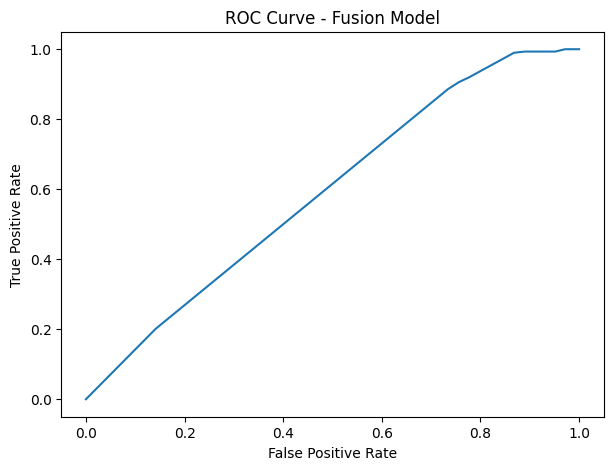

In [118]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    yf_test,
    fusion_probs
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Fusion Model")

plt.show()

In [119]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 7, 128)         │       123,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,701 (1.91 MB)

 Trainable params: 167,233 (653.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 334,468 (1.28 MB)

In [120]:
model.layers[-2]

<Dense name=dense_4, built=True>

In [121]:
from tensorflow.keras.models import Model

feature_extractor = Model(

    inputs=model.inputs,

    outputs=model.layers[-2].output

)

temporal_embeddings = feature_extractor.predict(X)

print(temporal_embeddings.shape)

print(temporal_embeddings[:5])

566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
(18086, 32)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]]


In [122]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

cv_scores = cross_val_score(

    fusion_model,

    fusion_features,

    y,

    cv=skf,

    scoring='accuracy'

)

print("CV Scores:", cv_scores)

print("Mean Accuracy:", cv_scores.mean())

CV Scores: [0.91735766 0.91761128 0.91761128 0.91761128 0.91733481]
Mean Accuracy: 0.9175052608428993


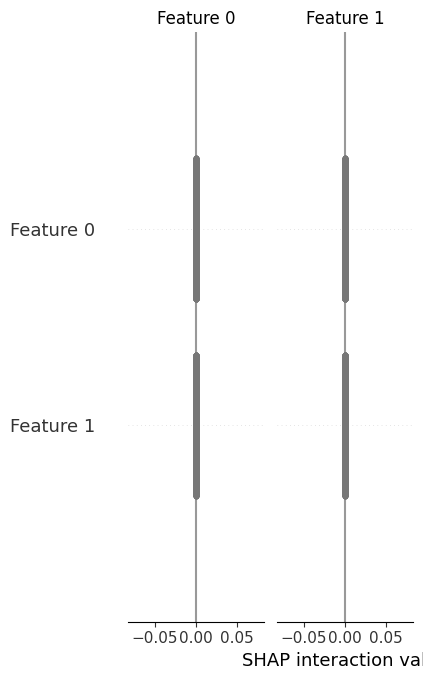

In [124]:
import shap

explainer = shap.TreeExplainer(
    fusion_model
)

shap_values = explainer.shap_values(
    Xf_test
)

shap.summary_plot(

    shap_values,

    Xf_test,

    show=False

)

plt.show()

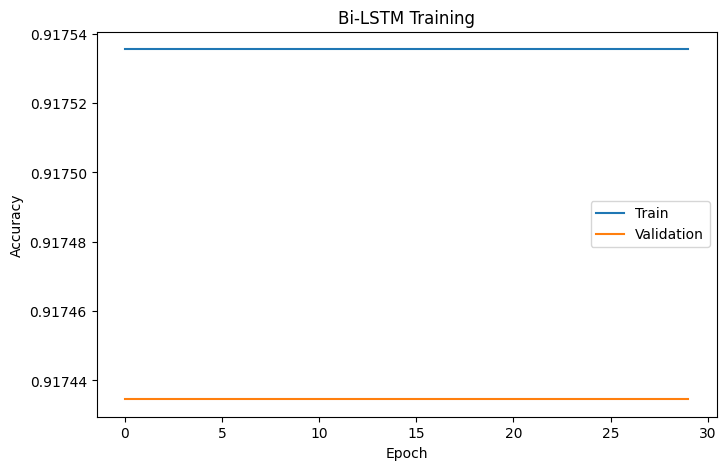

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Bi-LSTM Training')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

In [126]:
model.save(
    "bilstm_model.h5"
)

import joblib

joblib.dump(
    fusion_model,
    "fusion_model.pkl"
)

['fusion_model.pkl']

---

In [ ]:
import pandas as pd

nlp_df = pd.read_csv(
    "Combined Data.csv"
)

print(nlp_df.head())

print(nlp_df['status'].value_counts())

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


In [131]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

nlp_df['clean_text'] = nlp_df[
    'statement'
].apply(clean_text)

print(
    nlp_df['clean_text'].head()
)

0                                           oh my gosh
1    trouble sleeping confused mind restless heart ...
2    all wrong back off dear forward doubt stay in ...
3    ive shifted my focus to something else but im ...
4    im restless and restless its been a month now ...
Name: clean_text, dtype: object


In [132]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

nlp_df['label'] = label_encoder.fit_transform(
    nlp_df['status']
)

print(
    label_encoder.classes_
)

print(
    nlp_df[['status', 'label']].head()
)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
    status  label
0  Anxiety      0
1  Anxiety      0
2  Anxiety      0
3  Anxiety      0
4  Anxiety      0


In [133]:
!pip install transformers sentencepiece

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ----------------------------- ---------- 0.8/1.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 3.5 MB/s  0:00:00



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [134]:
from transformers import (
    BertTokenizer,
    BertModel
)

import torch

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

bert_model = BertModel.from_pretrained(
    'bert-base-uncased'
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [135]:
import numpy as np

def get_bert_embedding(text):

    inputs = tokenizer(

        text,

        return_tensors='pt',

        truncation=True,

        padding=True,

        max_length=128

    )

    with torch.no_grad():

        outputs = bert_model(**inputs)

    embedding = outputs.last_hidden_state[
        :,0,:      # CLS token
    ].numpy()

    return embedding[0]

# USE SMALLER SUBSET FIRST
sample_size = 3000

texts = nlp_df[
    'clean_text'
][:sample_size]

bert_embeddings = []

for i, text in enumerate(texts):

    emb = get_bert_embedding(text)

    bert_embeddings.append(emb)

    if i % 100 == 0:
        print(f"Processed {i}")

bert_embeddings = np.array(
    bert_embeddings
)

print(
    bert_embeddings.shape
)

Processed 0
Processed 100
Processed 200
Processed 300
Processed 400
Processed 500
Processed 600
Processed 700
Processed 800
Processed 900
Processed 1000
Processed 1100
Processed 1200
Processed 1300
Processed 1400
Processed 1500
Processed 1600
Processed 1700
Processed 1800
Processed 1900
Processed 2000
Processed 2100
Processed 2200
Processed 2300
Processed 2400
Processed 2500
Processed 2600
Processed 2700
Processed 2800
Processed 2900
(3000, 768)


In [136]:
y_nlp = nlp_df[
    'label'
][:sample_size]

print(y_nlp.shape)

(3000,)


In [137]:
from sklearn.model_selection import train_test_split

Xn_train, Xn_test, yn_train, yn_test = train_test_split(

    bert_embeddings,
    y_nlp,

    test_size=0.2,

    stratify=y_nlp,

    random_state=42

)

print(Xn_train.shape)

(2400, 768)


In [138]:
from sklearn.ensemble import RandomForestClassifier

nlp_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

nlp_model.fit(

    Xn_train,
    yn_train

)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
from sklearn.metrics import (

    classification_report,
    accuracy_score,
    confusion_matrix

)

nlp_preds = nlp_model.predict(
    Xn_test
)

print(

    classification_report(
        yn_test,
        nlp_preds
    )

)

print(

    "Accuracy:",

    accuracy_score(
        yn_test,
        nlp_preds
    )

)

print(

    confusion_matrix(
        yn_test,
        nlp_preds
    )

)

              precision    recall  f1-score   support

           0       0.86      0.50      0.64       147
           3       0.86      0.97      0.91       453

    accuracy                           0.86       600
   macro avg       0.86      0.74      0.77       600
weighted avg       0.86      0.86      0.84       600

Accuracy: 0.8583333333333333
[[ 74  73]
 [ 12 441]]


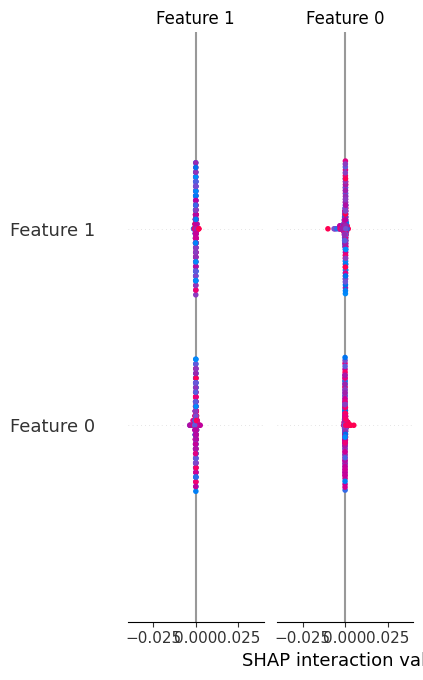

In [140]:
import shap

explainer = shap.TreeExplainer(
    nlp_model
)

shap_values = explainer.shap_values(
    Xn_test[:200]
)

shap.summary_plot(

    shap_values,

    Xn_test[:200],

    show=False

)

In [141]:
min_len = min(

    len(fusion_features),
    len(bert_embeddings)

)

final_features = np.concatenate(

    [

        fusion_features[:min_len],

        bert_embeddings[:min_len]

    ],

    axis=1

)

final_labels = y[:min_len]

print(final_features.shape)

(3000, 833)


In [142]:
from sklearn.model_selection import train_test_split

Xf_train, Xf_test, yf_train, yf_test = train_test_split(

    final_features,
    final_labels,

    test_size=0.2,

    stratify=final_labels,

    random_state=42

)

final_model = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

final_model.fit(

    Xf_train,
    yf_train

)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [143]:
from sklearn.metrics import (
    roc_auc_score
)

final_preds = final_model.predict(
    Xf_test
)

final_probs = final_model.predict_proba(
    Xf_test
)[:,1]

print(

    classification_report(
        yf_test,
        final_preds
    )

)

print(

    "ROC-AUC:",

    roc_auc_score(
        yf_test,
        final_probs,
        multi_class='ovr'
    )

)

              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93       525
         1.0       0.00      0.00      0.00        75

    accuracy                           0.87       600
   macro avg       0.44      0.50      0.47       600
weighted avg       0.77      0.87      0.82       600

ROC-AUC: 0.5915301587301587
